---
# IMPORTS

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, roc_curve

import tensorflow as tf
from tensorflow import keras

from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.inference.membership_inference import MembershipInferenceBlackBox

---
# LOAD DATA

In [2]:
vectorizer = joblib.load('vectorizer.pkl')

X      = pd.read_csv('X_train.csv').squeeze()
y      = pd.read_csv('y_train.csv').squeeze()
X_test = pd.read_csv('X_test.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

X_vec      = vectorizer.transform(X).toarray().astype(np.float32)
X_test_vec = vectorizer.transform(X_test).toarray().astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X_vec, y.values, test_size=0.2, random_state=42
)

y_test_arr = y_test.values

c:\Users\jaxel\anaconda3\envs\notebook\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jaxel\anaconda3\envs\notebook\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


---
# HELPER FUNCTIONS

In [3]:
def get_metrics(model, X, y):
    # Get model predictions as probabilities
    probs = model.predict(X, verbose=0).ravel()
    
    # Convert probabilities into binary predictions
    preds = (probs >= 0.5).astype(int)
    
    # Compute evaluation metrics
    return {
        "accuracy": accuracy_score(y, preds),
        "f1": f1_score(y, preds),
        "auc": roc_auc_score(y, probs),
        "probs": probs
    }

def clip_probs(p):
    # Limit probabilities to reduce overconfident predictions (privacy defense)
    return np.clip(p, 0.3, 0.7)


def add_noise(p):
    # Add small random noise to predictions to reduce membership inference signal
    return np.clip(p + np.random.normal(0, 0.05, p.shape), 0, 1)

---
# BASE MODEL

In [4]:
print("\n================ BASE MODEL =================")

# Load the pretrained model
model = keras.models.load_model("model.h5")

# Evaluate model performance on test set
base_metrics = get_metrics(model, X_test_vec, y_test_arr)

# Print standard evaluation results
print("Accuracy:", base_metrics["accuracy"])
print("F1 Score:", base_metrics["f1"])
print("ROC AUC:", base_metrics["auc"])


================ BASE MODEL =================


c:\Users\jaxel\anaconda3\envs\notebook\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Accuracy: 0.8779
F1 Score: 0.8818348978999323
ROC AUC: 0.94160392


---
# MIA ATTACK

In [5]:
print("\n================ MEMBERSHIP INFERENCE ATTACK =================")

# Loss function used by the ART classifier wrapper
loss_fn = tf.keras.losses.BinaryCrossentropy()

# Wrap the trained Keras model into an ART classifier
art_classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=2,
    input_shape=(X_train.shape[1],),
    loss_object=loss_fn,
    clip_values=(0.0, 1.0)
)

# Initialize Membership Inference Attack using a Random Forest attack model
attack = MembershipInferenceBlackBox(art_classifier, attack_model_type='rf')

# Train attack model using a subset of train (members) and test (non-members)
attack.fit(
    X_train[:2000], y_train[:2000],
    X_test_vec[:2000], y_test_arr[:2000]
)

# Predict membership for training and test samples
pred_train = attack.infer(X_train[:2000], y_train[:2000])
pred_test  = attack.infer(X_test_vec[:2000], y_test_arr[:2000])

# Create ground truth labels (1 = member, 0 = non-member)
y_true = np.concatenate([np.ones(2000), np.zeros(2000)])

# Combine predictions for evaluation
y_pred = np.concatenate([pred_train, pred_test])

# Compute attack effectiveness (higher AUC = worse privacy)
mia_auc_base = roc_auc_score(y_true, y_pred)

print("MIA AUC (Base):", mia_auc_base)


================ MEMBERSHIP INFERENCE ATTACK =================
MIA AUC (Base): 0.7195


---
# POISON ATTACK

In [6]:
print("\n================ POISONING ATTACK =================")

# Create a copy of training labels
y_poison = y_train.copy()

# Randomly select 30% of training data indices
idx = np.random.choice(len(y_poison), int(0.3 * len(y_poison)), replace=False)

# Flip labels (0 → 1, 1 → 0) to poison the dataset
y_poison[idx] = 1 - y_poison[idx]

# Clone the original model architecture
poison_model = keras.models.clone_model(model)

# Compile the poisoned model
poison_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model on poisoned labels
poison_model.fit(X_train, y_poison, epochs=5, verbose=0)

# Evaluate performance after poisoning attack
poison_metrics = get_metrics(poison_model, X_test_vec, y_test_arr)

print("Poisoned Accuracy:", poison_metrics["accuracy"])


================ POISONING ATTACK =================
Poisoned Accuracy: 0.6814


---
# DEFENSES

DEFENSE 1: Data Filtering

In [7]:
print("\n================ DEFENSES =================")

# Train a simple reference model to detect suspicious samples
ref_model = LogisticRegression(max_iter=1000)
ref_model.fit(X_train, y_train)

# Get model predictions on training data
preds = ref_model.predict(X_train)

# Get prediction confidence (how sure the model is)
conf = np.max(ref_model.predict_proba(X_train), axis=1)

# Keep only samples that are correctly classified with high confidence
# This helps remove noisy / poisoned data points
mask = (preds == y_train) & (conf > 0.6)

# Filter out suspicious samples
X_clean = X_train[mask]
y_clean = y_train[mask]

# Show how many samples were removed
print("Removed samples:", len(X_train) - len(X_clean))


================ DEFENSES =================
Removed samples: 4024


DEFENSE 2: Clipping + Noise

In [8]:
# ======================= DEFENSE MODEL ==========================
# Create a fresh model based on original architecture
defense_model = keras.models.clone_model(model)

# Compile the model
defense_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model on cleaned (filtered) dataset
defense_model.fit(X_clean, y_clean, epochs=5, verbose=0)

# Evaluate normal model performance after defense
def_metrics = get_metrics(defense_model, X_test_vec, y_test_arr)

In [9]:
# =================== MIA DEFENSE (NOISE + CLIP) ================
# Get prediction probabilities for train/test data
train_probs_def = defense_model.predict(X_clean).ravel()
test_probs_def  = defense_model.predict(X_test_vec).ravel()

# Apply probability clipping + noise to reduce overconfidence
train_probs_def = add_noise(clip_probs(train_probs_def))
test_probs_def  = add_noise(clip_probs(test_probs_def))

# Build dataset for membership inference attack evaluation
X_atk = np.concatenate([train_probs_def, test_probs_def])
y_atk = np.concatenate([np.ones(len(train_probs_def)), np.zeros(len(test_probs_def))])

# Train simple attack model (logistic regression)
atk_model = LogisticRegression().fit(X_atk.reshape(-1, 1), y_atk)

# Get attack probabilities
atk_probs = atk_model.predict_proba(X_atk.reshape(-1, 1))[:, 1]

# Measure privacy leakage after defense
mia_auc_def = roc_auc_score(y_atk, atk_probs)



875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [10]:
# ======================== RESULTS ===============================
print("Defended Accuracy:", def_metrics["accuracy"])
print("MIA AUC (Defended):", mia_auc_def)

Defended Accuracy: 0.8893
MIA AUC (Defended): 0.5024250893623106


---
# FINAL COMPARISON

In [11]:
print("\n================ FINAL COMPARISON =================")

print(f"Before Attack  → Acc: {base_metrics['accuracy']:.4f}")
print(f"After Attack   → Acc: {poison_metrics['accuracy']:.4f}")
print(f"After Defense  → Acc: {def_metrics['accuracy']:.4f}")

print(f"\nMIA AUC Before Defense : {mia_auc_base:.4f}")
print(f"MIA AUC After Defense  : {mia_auc_def:.4f}")


================ FINAL COMPARISON =================
Before Attack  → Acc: 0.8779
After Attack   → Acc: 0.6814
After Defense  → Acc: 0.8893

MIA AUC Before Defense : 0.7195
MIA AUC After Defense  : 0.5024


---
# PLOTS

In [12]:
def plot_confidence(train_probs, test_probs, title):
    # Plot distribution of prediction confidence for train vs test data
    plt.figure()
    
    plt.hist(train_probs, bins=50, alpha=0.5, label="Train")
    plt.hist(test_probs, bins=50, alpha=0.5, label="Test")
    
    plt.title(title)
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


def plot_accuracy(base, poison, defense):
    # Compare model accuracy before attack, after poisoning, and after defense
    plt.figure()
    
    plt.bar(["Base", "Poisoned", "Defended"], [base, poison, defense])
    
    plt.title("Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.show()


def plot_mia_auc(base, poison, defense):
    # Compare privacy leakage (MIA AUC) across different model states
    plt.figure()
    
    plt.bar(["Base", "Poisoned", "Defended"], [base, poison, defense])
    
    plt.title("MIA AUC Comparison (Privacy Leakage)")
    plt.ylabel("AUC")
    plt.show()

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


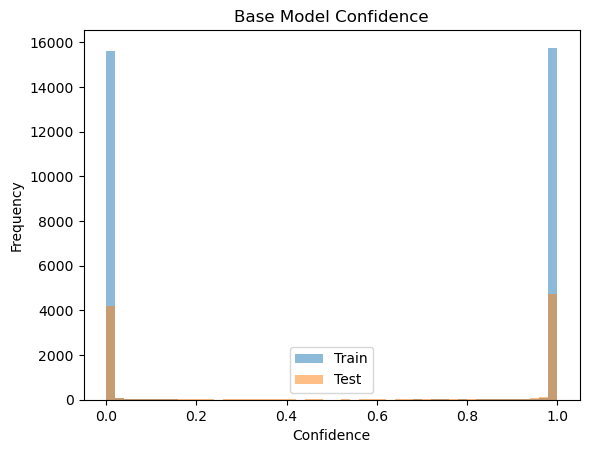

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


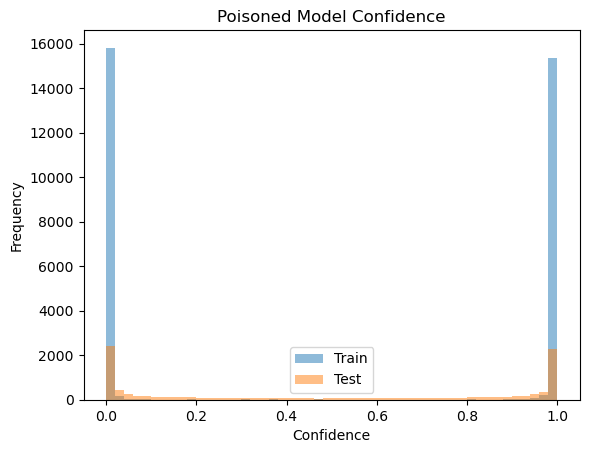

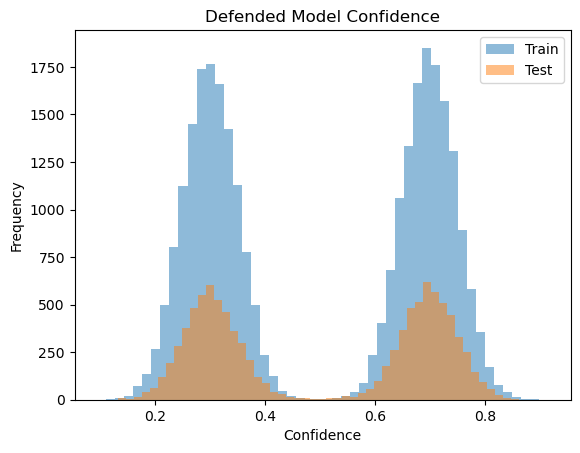

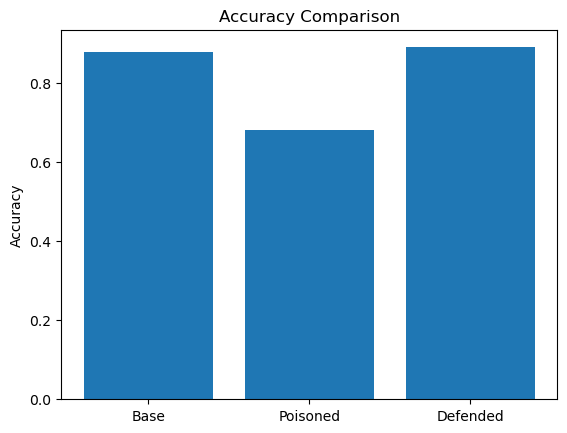

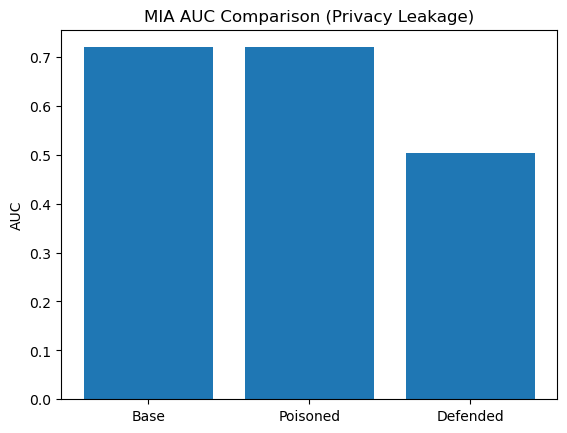

In [13]:
plot_confidence(
    model.predict(X_train).ravel(),
    model.predict(X_test_vec).ravel(),
    "Base Model Confidence"
)

plot_confidence(
    poison_model.predict(X_train).ravel(),
    poison_model.predict(X_test_vec).ravel(),
    "Poisoned Model Confidence"
)

plot_confidence(
    train_probs_def,
    test_probs_def,
    "Defended Model Confidence"
)

plot_accuracy(
    base_metrics["accuracy"],
    poison_metrics["accuracy"],
    def_metrics["accuracy"]
)

plot_mia_auc(
    mia_auc_base,
    mia_auc_base,
    mia_auc_def
)